# NB 15 — Prediction prototype (PCA)

End-to-end predict path on a single anomaly slice from `test_intern_raw.npy`.
Goal: prove a clean `predict_slice(df_raw, threshold)` contract and the four
prediction-phase plots in `viz.py`, so the team can wire this into the API
and the frontend.

This notebook is a prototype — it does **not** modify `predictor_pca.py`.
The function at the bottom of the notebook is the proposed v2 contract.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sentinel.params import PCA_THRESHOLD, WINDOW_SIZE
from sentinel.ml_logic.data import MODELS_DIR, PROCESSED_DIR
from sentinel.ml_logic.scoring import score_windows, window_scores_only
from sentinel.ml_logic.metrics import event_f05, row_precision_recall
from sentinel.ml_logic.viz import (
    plot_score_distribution,
    plot_score_timeline,
    plot_event_zoom_with_score,
    plot_confusion_and_channel_errors,
)

sns.set_theme(style="whitegrid")
print("threshold:", PCA_THRESHOLD, " window:", WINDOW_SIZE)

threshold: 0.060404  window: 100


## 2. Load artefacts

Everything the predictor needs lives in `models/` and `data/processed/`:
the fitted PCA, the RobustScaler, and the list of 58 target channels.

In [2]:
with open(MODELS_DIR / "pca.pkl", "rb") as f:
    pca = pickle.load(f)
with open(MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(PROCESSED_DIR / "preprocessing_config.json") as f:
    features = json.load(f)["target_channels"]

print("PCA components:", pca.n_components_)
print("scaler fitted on", scaler.n_features_in_, "features")
print("features:", len(features), "channels")

PCA components: 38
scaler fitted on 58 features
features: 58 channels


## 3. Pick a slice

We load the held-out `test_intern_raw.npy` (raw, **unscaled**) together with
its binary labels, then cut a window around one anomaly event with
±500 context rows.

In [3]:
X_raw_all = np.load(PROCESSED_DIR / "test_intern_raw.npy", mmap_mode="r")
y_all     = np.load(PROCESSED_DIR / "y_test_intern.npy")
print("test_intern:", X_raw_all.shape, " anomalies:", int(y_all.sum()))

# Big, clearly visible event (1480 rows)
EV_START = 400_398
EV_END   = 401_877
CONTEXT  = 500

lo = max(0, EV_START - CONTEXT)
hi = min(len(X_raw_all), EV_END + CONTEXT + 1)

df_slice = pd.DataFrame(
    np.asarray(X_raw_all[lo:hi]),
    columns=features,
    index=np.arange(lo, hi),
)
df_slice["is_anomaly"] = y_all[lo:hi].astype(np.int8)
print("slice rows:", len(df_slice), " anomalies:", int(df_slice['is_anomaly'].sum()))

test_intern: (2186220, 58)  anomalies: 214961
slice rows: 2480  anomalies: 1480


## 4. Prototype `predict_slice`

Proposed contract for `predictor_pca.py v2`: one call returns everything
the frontend needs for a slice — labels, scores, per-channel MSE for the
top-error diagnostic, the threshold that produced the labels, and the
feature list (so the caller can line up columns).

The function is deliberately pure: no file I/O, no plotting, no globals.

In [4]:
def predict_slice(df_raw: pd.DataFrame, threshold: float = PCA_THRESHOLD) -> dict:
    """
    Run the PCA anomaly detector on a slice of raw sensor data.

    Parameters
    ----------
    df_raw    : DataFrame with at least the 58 target channels as columns.
                A row-level ``is_anomaly`` column is allowed but ignored.
    threshold : decision threshold on the window-mean MSE.

    Returns
    -------
    dict with keys
        labels          : int8  (n_rows,)  0 = nominal, 1 = anomaly
        scores          : float32 (n_rows,) row-level anomaly score
        per_channel_mse : float32 (58,) mean reconstruction MSE per channel
        threshold       : the threshold used
        features        : list[str] channel order used by the model
    """
    X = df_raw[features].values.astype(np.float32)
    X_scaled = scaler.transform(X).astype(np.float32)

    # row-level scores (what we threshold on)
    scores = score_windows(pca, X_scaled, win=WINDOW_SIZE)
    labels = (scores > threshold).astype(np.int8)

    # per-channel MSE for the diagnostic plot
    n_complete = X_scaled.shape[0] // WINDOW_SIZE
    if n_complete > 0:
        X_win  = X_scaled[:n_complete * WINDOW_SIZE].reshape(n_complete, WINDOW_SIZE, X_scaled.shape[1])
        X_flat = X_win.reshape(n_complete, WINDOW_SIZE * X_scaled.shape[1])
        X_hat  = pca.inverse_transform(pca.transform(X_flat)).reshape(n_complete, WINDOW_SIZE, X_scaled.shape[1])
        per_channel_mse = ((X_win - X_hat) ** 2).mean(axis=(0, 1)).astype(np.float32)
    else:
        per_channel_mse = np.zeros(len(features), dtype=np.float32)

    return {
        "labels"          : labels,
        "scores"          : scores,
        "per_channel_mse" : per_channel_mse,
        "threshold"       : float(threshold),
        "features"        : features,
    }

## 5. Run prediction + sanity assertions

In [5]:
out = predict_slice(df_slice)

# Contract asserts — fail fast if the shape contract changes
assert set(out) == {"labels", "scores", "per_channel_mse", "threshold", "features"}
assert out["labels"].shape == (len(df_slice),)
assert out["scores"].shape == (len(df_slice),)
assert out["per_channel_mse"].shape == (len(features),)
assert out["labels"].dtype == np.int8
assert set(np.unique(out["labels"])).issubset({0, 1})

print("rows         :", len(df_slice))
print("true anom    :", int(df_slice['is_anomaly'].sum()))
print("predicted    :", int(out['labels'].sum()))
print("score min/max:", float(out['scores'].min()), '/', float(out['scores'].max()))
print("threshold    :", out['threshold'])

rows         : 2480
true anom    : 1480
predicted    : 0
score min/max: 0.03305282071232796 / 0.04402969777584076
threshold    : 0.060404


## 6. Metrics on the slice

Event-wise F0.5 is the primary tuning metric; the row-level numbers feed
the frontend headline tiles.

In [6]:
y_true = df_slice["is_anomaly"].values
y_pred = out["labels"]

ef05 = event_f05(y_true, y_pred)
rpr  = row_precision_recall(y_true, y_pred)

print("event F0.5  :", ef05['f_score'],
      f"  (tp={ef05['tp_events']}, fn={ef05['fn_events']}, fp_pred={ef05['fp_pred_events']})")
print("row   F1    :", rpr['f1'],
      f"  (precision={rpr['precision']}, recall={rpr['recall']})")

event F0.5  : 0.0   (tp=0, fn=1, fp_pred=0)
row   F1    : 0.0   (precision=0.0, recall=0.0)


## 7. Visuals

Four plots, one per cell — same set the API will expose to the frontend.

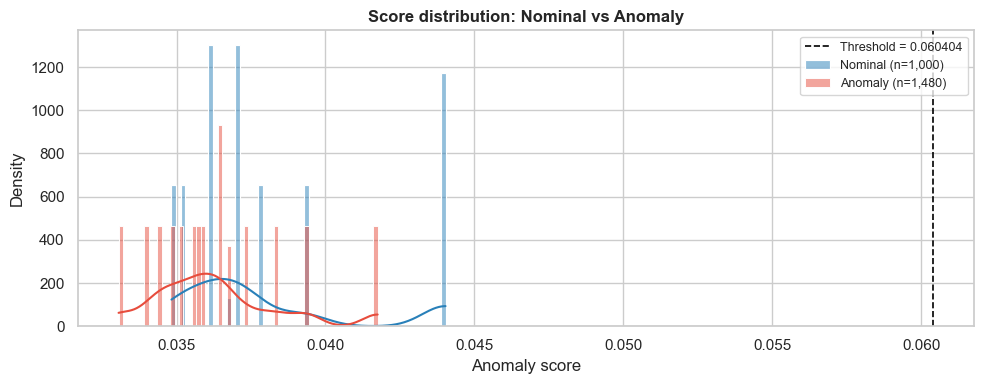

In [7]:
plot_score_distribution(out["scores"], y_true, out["threshold"]);

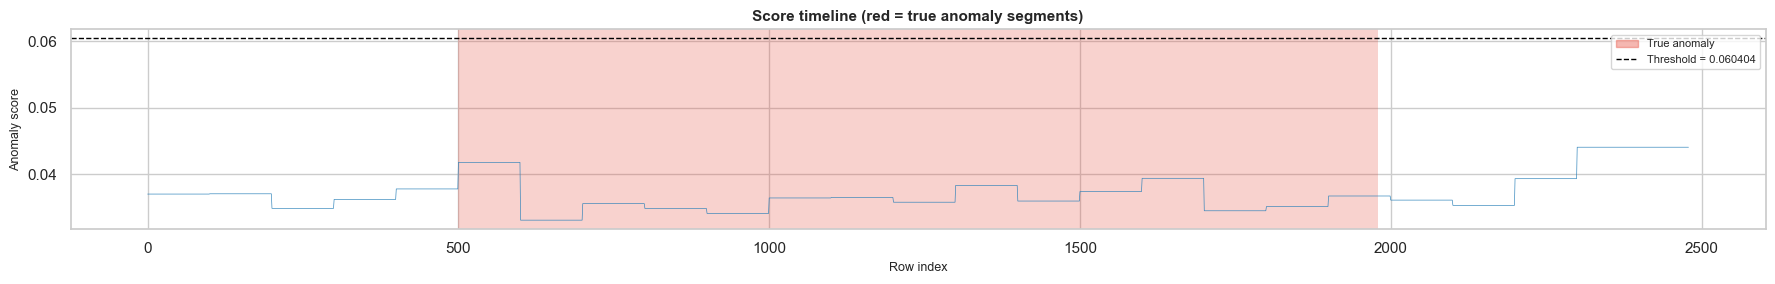

In [8]:
plot_score_timeline(out["scores"], y_true, out["threshold"]);

top channels: ['channel_76', 'channel_75', 'channel_72', 'channel_74']


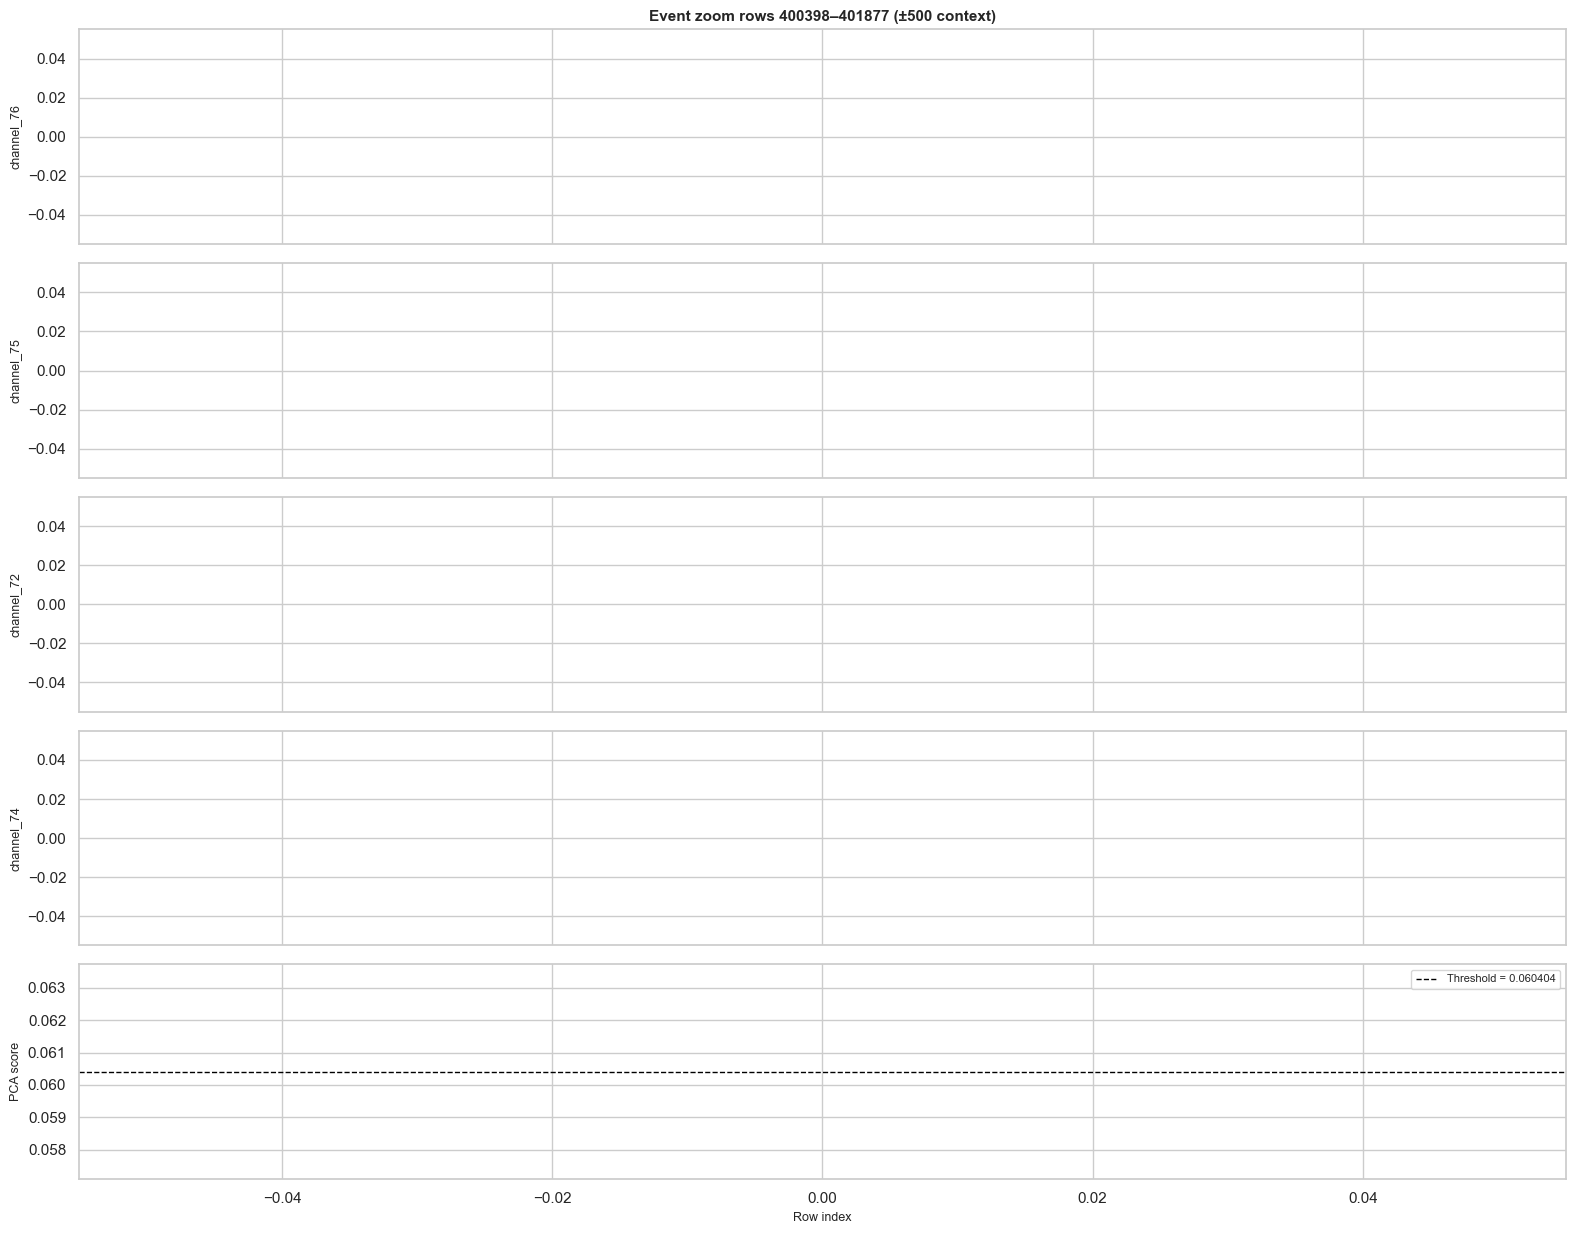

In [9]:
# Rank channels by reconstruction error and zoom in on the worst four
top_channels = [
    features[i]
    for i in np.argsort(out["per_channel_mse"])[::-1][:4]
]
print("top channels:", top_channels)

plot_event_zoom_with_score(
    df_raw=df_slice,
    scores=out["scores"],
    seg_start=EV_START,
    seg_end=EV_END,
    channels=top_channels,
    threshold=out["threshold"],
    context=CONTEXT,
);

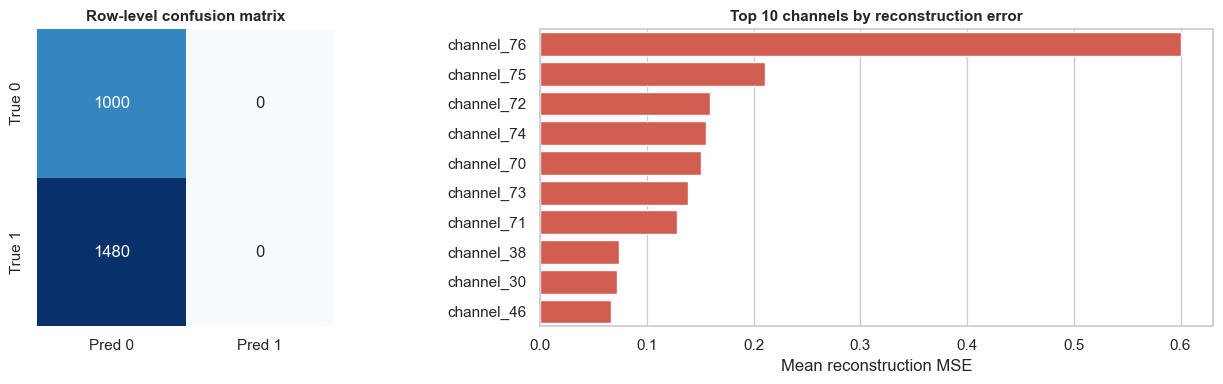

In [10]:
plot_confusion_and_channel_errors(
    y_true=y_true,
    y_pred=y_pred,
    per_channel_mse=out["per_channel_mse"],
    channel_names=features,
    top_k=10,
);

## 8. Contract for `predictor_pca.py` v2

The existing `predict(X_raw, threshold, return_scores=False)` covers the
Kaggle-submission path (one array of labels over the full test set). The
frontend needs more than that on a per-slice basis — at minimum: scores,
per-channel MSE, and the threshold actually used.

Proposed next step: promote `predict_slice` (above) into
`src/sentinel/ml_logic/predictor_pca.py` with this contract:

```python
def predict_slice(df_raw: pd.DataFrame, threshold: float = PCA_THRESHOLD) -> dict:
    '''Returns {labels, scores, per_channel_mse, threshold, features}.'''
```

Everything else (lazy model loading, the thin `predict` wrapper) stays
as-is. The four `viz.py` plots then take `out['scores']`, `out['labels']`,
and `out['per_channel_mse']` directly — no further glue code needed.